In [2]:
import os
import pandas as pd
import cadquery as cq

# Chemin vers le dossier contenant les fichiers STEP
dossier_stp = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D"
# print(os.getcwd())
# Initialisation d'une liste pour stocker les données
data = []

# Parcourir tous les fichiers dans le dossier
for fichier in os.listdir(dossier_stp):
    if fichier.endswith(".stp") or fichier.endswith(".step"):
        path_to_stp_file = os.path.join(dossier_stp, fichier)

        try:
            # Charger le modèle 3D à partir du fichier STEP
            model = cq.importers.importStep(path_to_stp_file)
            shape = model.val()

            # Extraire les caractéristiques géométriques
            volume = shape.Volume()
            surface = shape.Area()

            # Extraire les caractéristiques topologiques
            faces = shape.Faces()
            edges = shape.Edges()
            vertices = shape.Vertices()

            # Ajouter au DataFrame
            data.append({
                "Fichier": fichier,
                "Volume": volume,
                "Surface": surface,
                "Faces": len(faces),
                "Aretes": len(edges),
                "Sommets": len(vertices),
                "Relations_Face_Arete": sum(len(face.Edges()) for face in faces),
                "Relations_Face_Sommet": sum(len(face.Vertices()) for face in faces),
                "Relations_Arete_Sommet": sum(len(edge.Vertices()) for edge in edges),
                # Ajoutez d'autres informations topologiques selon vos besoins
            })
        except Exception as e:
            print(f"Erreur lors du traitement du fichier {fichier}: {e}")

# Créer un DataFrame à partir des données
df_pieces = pd.DataFrame(data)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x0000023A4725D810>>
Traceback (most recent call last):
  File "c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\ipykernel\ipkernel.py", line 785, in _clean_thread_parent_frames
    active_threads = {thread.ident for thread in threading.enumerate()}
                                                 ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\kevin\anaconda3\envs\Alstom\Lib\threading.py", line 1501, in enumerate
    def enumerate():
    
KeyboardInterrupt: 


In [ ]:
import os
import pandas as pd
import cadquery as cq

# Chemin vers le dossier contenant les fichiers STEP
dossier_stp = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D"
# print(os.getcwd())
# Initialisation d'une liste pour stocker les données
data = []

# Parcourir tous les fichiers dans le dossier
for fichier in os.listdir(dossier_stp):
    if fichier.endswith(".stp") or fichier.endswith(".step"):
        path_to_stp_file = os.path.join(dossier_stp, fichier)

        try:
            # Charger le modèle 3D à partir du fichier STEP
            model = cq.importers.importStep(path_to_stp_file)
            shape = model.val()

            # Extraire les caractéristiques
            volume = shape.Volume()
            surface = shape.Area()
            bbox = shape.BoundingBox()
            longueur, largeur, hauteur = bbox.xlen, bbox.ylen, bbox.zlen
            faces = len(shape.Faces())
            aretes = len(shape.Edges())
            sommets = len(shape.Vertices())

            # Ajouter au DataFrame
            data.append({
                "Fichier": fichier,
                "Volume": volume,
                "Surface": surface,
                "Lng_BBox": longueur,
                "Lrg_BBox": largeur,
                "Hauteur_BBox": hauteur,
                "Faces": faces,
                "Aretes": aretes,
                "Sommets": sommets
            })
        except Exception as e:
            print(f"Erreur lors du traitement du fichier {fichier}: {e}")

# Créer un DataFrame à partir des données
df_pieces = pd.DataFrame(data)

In [ ]:
df_entry_copy = df_pieces.copy()
df_entry_copy.set_index("Fichier", inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import plotly.graph_objects as go
from OCC.Display.SimpleGui import init_display
from OCC.Extend.DataExchange import read_step_file
import pythreejs as p3js
import cadquery as cq
from sklearn.metrics import silhouette_score

def scale_and_pca(data):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    pca = PCA()
    data_pca = pca.fit_transform(data_scaled)

    return data_pca, scaler, pca

def scaler_transform(df_entry):
    # Exclure les colonnes non numériques
    numeric_columns = df_entry.select_dtypes(include=[np.number]).columns
    df_numeric = df_entry[numeric_columns]

    # Centrer et réduire :
    scaler = StandardScaler()
    data_pieces_scaler = scaler.fit_transform(df_numeric)

    # Constructeur ACP
    mypca = PCA()
    mypca.fit(data_pieces_scaler)

    # Utilisation de l'ACP pour réduire la dimension
    data_pieces_pca = mypca.transform(data_pieces_scaler)

    return data_pieces_pca


def nearest_neighbor(df_entry, nom_fichier):
    df_entry_copy = df_entry.copy()
    df_entry_copy.set_index("Fichier", inplace=True)

    # Centrer réduire :
    scaler = StandardScaler()
    scaler.fit(df_entry_copy)
    data_pieces_scaler = scaler.transform(df_entry_copy)

    # Constructeur ACP
    mypca = PCA()
    mypca.fit(data_pieces_scaler)

    # Utilisation de l'ACP pour réduire la dimension
    data_pieces_pca = mypca.transform(data_pieces_scaler)

    # Utilisation de NearestNeighbors pour trouver le voisin le plus proche
    neighbors_model = NearestNeighbors(n_neighbors=2)  # Considering the current point itself
    neighbors_model.fit(data_pieces_pca)

    # Trouver les indices et distances des voisins les plus proches
    distances, indices = neighbors_model.kneighbors(data_pieces_pca)

    # Trouver l'index du voisin le plus proche (éviter le premier index qui est l'élément lui-même)
    neighbor_index = indices[df_entry_copy.index == nom_fichier, 1][0]

    # Retourner la ligne du dataframe correspondant au voisin le plus proche
    return df_entry_copy.iloc[neighbor_index]


def plot_original_and_neighbor(df_pieces, nom_piece, df_clustered, neighbors_df):
    # Extraire les informations de la pièce initiale
    piece_initiale = df_pieces[df_pieces['Fichier'] == nom_piece]

    # Extraire le cluster de la pièce initiale
    cluster_piece_initiale = df_clustered[df_clustered['Fichier'] == nom_piece]['Cluster'].values[0]

    # Extraire le voisin le plus proche de la pièce initiale
    voisin = neighbors_df.iloc[0]

    # Convertir les valeurs numpy.float64 en float
    x_piece_initiale = float(piece_initiale['Lng_BBox'])
    y_piece_initiale = float(piece_initiale['Lrg_BBox'])
    z_piece_initiale = float(piece_initiale['Hauteur_BBox'])

    x_voisin = float(voisin['Lng_BBox'])
    y_voisin = float(voisin['Lrg_BBox'])
    z_voisin = float(voisin['Hauteur_BBox'])



    # Créer une figure 3D
    fig = go.Figure()

    # Ajouter la pièce initiale au graphe
    fig.add_trace(go.Scatter3d(
        x=[x_piece_initiale],
        y=[y_piece_initiale],
        z=[z_piece_initiale],
        mode='markers',
        marker=dict(size=10, color='blue'),
        name='Pièce Initiale'
    ))

    # Ajouter le voisin au graphe
    fig.add_trace(go.Scatter3d(
        x=[x_voisin],
        y=[y_voisin],
        z=[z_voisin],
        mode='markers',
        marker=dict(size=10, color='red'),
        name='Voisin'
    ))

    # Définir le layout
    fig.update_layout(
        scene=dict(
            xaxis_title='Longueur BBox',
            yaxis_title='Largeur BBox',
            zaxis_title='Hauteur BBox',
        ),
        title=f'Pièce Initiale et Voisin - Cluster {cluster_piece_initiale}',
    )

    # Afficher la figure
    fig.show()
    return None

def plot_dataframe(df_entry):
    
    data_pca = scaler_transform(df_entry)

    colors = px.colors.qualitative.swatches()

    # Création d'une figure interactive en 3D avec Plotly Express
    fig = px.scatter_3d(df_entry, x=data_pca[:, 0], y=data_pca[:, 1], z=data_pca[:, 2],
                        color='Cluster', opacity=0.8, size_max=20,
                        title='Clusters obtenus par DBSCAN après normalisation',
                        color_discrete_sequence=colors,
                        hover_data={'Cluster': True, 'Fichier': True})
    # Affichage de la figure interactive
    fig.show() # ou return fig et tu fais un plot_dataframe(df_entry).show() sur ta page web

@staticmethod
def elbow_method(df_entry, k_range=range(1, 11)):
    # Méthode du coude pour trouver une valeur pertinente pour epsilon

    # Sélectionner uniquement les colonnes numériques
    numeric_columns = df_entry.select_dtypes(include=[np.number]).columns
    df_numeric = df_entry[numeric_columns]

    # Appliquer la mise à l'échelle et l'ACP
    data_pca, _, _ = scale_and_pca(df_numeric)

    # Calculer la distance moyenne des k-voisins pour différentes valeurs de k
    neighbors = NearestNeighbors(n_neighbors=max(k_range) + 1)
    neighbors.fit(data_pca)
    distances, _ = neighbors.kneighbors(data_pca)

    # Calculer la distance moyenne des k-voisins pour chaque point
    avg_distances = np.mean(distances[:, 1:], axis=1)

    # Tracer la courbe
    plt.plot(list(k_range), avg_distances, marker='o')  # Convertir k_range en liste
    plt.title('Elbow Method for Optimal Epsilon')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Average Distance')
    plt.show()



@staticmethod
def evaluate_clusters(data_pca, clusters):
    # Utiliser l'indice de silhouette pour évaluer la qualité des clusters
    silhouette_avg = silhouette_score(data_pca, clusters)
    print(f"Silhouette Score: {silhouette_avg}")


In [ ]:

def clustering(df_entry):
    df_copy = df_entry.copy()
    df_copy.set_index("Fichier", inplace=True)

    data_pca, _, _ = scale_and_pca(df_copy)

    dbscan = DBSCAN(eps=0.1, min_samples=1)
    clusters = dbscan.fit_predict(data_pca)

    df_copy['Cluster'] = clusters
    df_return = df_copy.reset_index()

    return df_return

In [ ]:
plot_dataframe(df_entry_copy)

ValueError: Value of 'hover_data_0' is not the name of a column in 'data_frame'. Expected one of ['Volume', 'Surface', 'Lng_BBox', 'Lrg_BBox', 'Hauteur_BBox', 'Faces', 'Aretes', 'Sommets'] but received: Cluster

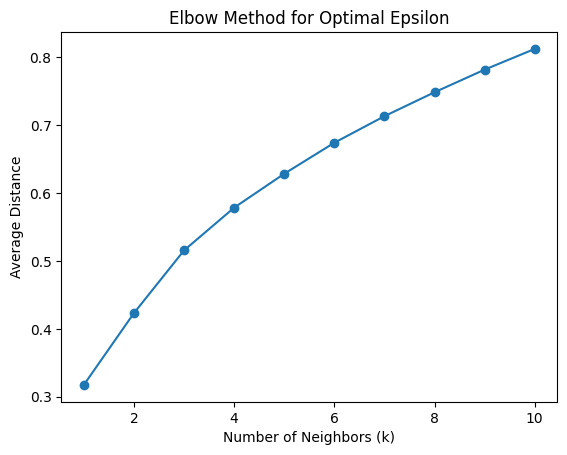

Optimal Epsilon: 0.8122437577187188


In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

def elbow_method(data, k_range=range(1, 11)):
    # Select only numeric columns
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    df_numeric = data[numeric_columns]

    # Apply scaling and PCA
    data_pca, _, _ = scale_and_pca(df_numeric)

    # Calculate average distance to k-nearest neighbors for different values of k
    avg_distances = []
    for k in k_range:
        neighbors_model = NearestNeighbors(n_neighbors=k + 1)
        neighbors_model.fit(data_pca)
        distances, _ = neighbors_model.kneighbors(data_pca)
        avg_distances.append(np.mean(distances[:, 1:]))

    # Plot the elbow curve
    plt.plot(list(k_range), avg_distances, marker='o')
    plt.title('Elbow Method for Optimal Epsilon')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Average Distance')
    plt.show()

    # Find the elbow point
    elbow_point = np.argmin(np.diff(avg_distances)) + 1
    optimal_epsilon = avg_distances[elbow_point]

    return optimal_epsilon

# Test the elbow method to find optimal epsilon
optimal_epsilon = elbow_method(df_pieces)
print(f'Optimal Epsilon: {optimal_epsilon}')


In [ ]:
from collections import Counter

In [ ]:
from sklearn.cluster import KMeans

# Assuming df_entry_copy is your data
k_values = range(2, 20)

best_k = None
best_kmeans_score = float('-inf')

for k_val in k_values:
    kmeans_labels = KMeans(n_clusters=k_val).fit(df_entry_copy).labels_
    kmeans_score = silhouette_score(df_entry_copy, kmeans_labels)
    
    if kmeans_score > best_kmeans_score:
        best_kmeans_score = kmeans_score
        best_k = k_val

# Print the best K-Means parameters and score
print(f"Best K-Means silhouette score: {best_kmeans_score}")
print(f"Best number of clusters (K): {best_k}")


Best K-Means silhouette score: 0.9679383687366366
Best number of clusters (K): 2


c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

In [ ]:
from sklearn.cluster import KMeans

def kmeans_clustering(df_entry_copy, n_clusters=2):
    """
    Perform K-Means clustering on a DataFrame with numeric data.

    Parameters:
    - df_entry_copy: DataFrame with numeric data and string index.
    - n_clusters: Number of clusters for K-Means (default is 2).

    Returns:
    - df_with_clusters: DataFrame with an additional 'Cluster' column indicating the cluster assignments.
    """

    # Extract numeric data
    numeric_columns = df_entry_copy.select_dtypes(include=[np.number]).columns
    df_numeric = df_entry_copy[numeric_columns]

    # Perform K-Means clustering
    kmeans = KMeans(n_clusters=n_clusters)
    clusters = kmeans.fit_predict(df_numeric)

    # Add 'Cluster' column to the original DataFrame
    df_with_clusters = df_entry_copy.copy()
    df_with_clusters['Cluster'] = clusters

    return df_with_clusters

# Example Usage:
# Assuming df_entry_copy is your DataFrame with float data and a string index
# Adjust the value of n_clusters as needed
result_df = kmeans_clustering(df_entry_copy, n_clusters=2)


c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
result_df.reset_index(inplace=True)

In [ ]:
plot_dataframe(result_df)

In [ ]:
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.TopoDS import topods
from OCC.Core.BRepMesh import BRepMesh_IncrementalMesh
from OCC.Core.TopExp import TopExp_Explorer
from OCC.Core.TopAbs import TopAbs_FACE
from OCC.Core.BRep import BRep_Builder
from OCC.Display.SimpleGui import init_display

def load_step(file_path):
    # Charger le fichier STEP
    step_reader = STEPControl_Reader()
    step_reader.ReadFile(file_path)
    step_reader.TransferRoots()

    shape = step_reader.OneShape()

    return shape

def convert_to_mesh(shape):
    # Convertir la forme en maillage
    mesh = topods.TopoDS_Face()
    builder = BRep_Builder()
    builder.MakeFace(mesh)

    mesh_incremental = BRepMesh_IncrementalMesh(mesh, 0.1)
    mesh_incremental.Perform()

    return mesh

def extract_mesh_points(mesh):
    # Extraire les points du maillage
    points = []

    explorer = TopExp_Explorer(mesh, TopAbs_FACE)
    while explorer.More():
        face = topods.TopoDS_Face(explorer.Current())
        mesh_face = BRepMesh_IncrementalMesh(face, 0.1)
        mesh_face.Perform()
        points.extend(mesh_face.Points())

        explorer.Next()

    return points

# Exemple d'utilisation
file_path_1 = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/M3D-207789_--A_CATPART_1.stp"
file_path_2 = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/M3D-248214_A.stp"


shape = load_step(file_path_1)
mesh = convert_to_mesh(shape)
mesh_points = extract_mesh_points(mesh)

# Maintenant, vous pouvez utiliser ces points pour la comparaison


: 

In [ ]:
from pystep import step_parser
import numpy as np

def convert_stp_to_points(file_path):
    # Charger le fichier STP
    step_model = step_parser.parse(file_path)

    # Extraire les points du modèle
    points = []
    for shape in step_model.shapes:
        if shape.geometry.is_a("CartesianPoint"):
            coords = shape.geometry.coordinates
            points.append(coords)

    return np.array(points)

# Exemple d'utilisation
file_path_1 = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/M3D-207789_--A_CATPART_1.stp"
file_path_2 = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/M3D-248214_A.stp"

points1 = convert_stp_to_points(file_path_1)
points2 = convert_stp_to_points(file_path_2)

# Maintenant, vous pouvez comparer les ensembles de points comme nécessaire
# (par exemple, en utilisant des mesures de distance comme la distance euclidienne)


ModuleNotFoundError: No module named 'pystep'

In [ ]:
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.BRepMesh import BRepMesh_IncrementalMesh
from OCC.Core.TopExp import TopExp_Explorer
from OCC.Core.TopAbs import TopAbs_FACE
from OCC.Core.BRep import BRep_Builder
from OCC.Core.TopoDS import topods
import tripy
import numpy as np

def load_step(file_path):
    # Charger le fichier STEP
    step_reader = STEPControl_Reader()
    step_reader.ReadFile(file_path)
    step_reader.TransferRoots()

    shape = step_reader.OneShape()

    return shape

def convert_to_mesh(shape):
    # Convertir la forme en maillage
    mesh = topods.TopoDS_Face()
    builder = BRep_Builder()
    builder.MakeFace(mesh)

    mesh_incremental = BRepMesh_IncrementalMesh(mesh, 0.1)
    mesh_incremental.Perform()

    return mesh

def extract_mesh_points(mesh):
    # Extraire les points du maillage
    points = []

    explorer = TopExp_Explorer(mesh, TopAbs_FACE)
    while explorer.More():
        face = topods.TopoDS_Face(explorer.Current())
        mesh_face = BRepMesh_IncrementalMesh(face, 0.1)
        mesh_face.Perform()
        points.extend(mesh_face.Points())

        explorer.Next()

    return np.array(points)

def calculate_similarity(model1_points, model2_points):
    # Exemple simple : Calculer la distance moyenne entre les points des deux modèles
    average_distance = np.mean(np.linalg.norm(model1_points - model2_points, axis=1))
    similarity_percentage = 1 - average_distance / np.max(np.linalg.norm(model1_points, axis=1))

    return similarity_percentage

# Exemple d'utilisation
file_path_1 = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/M3D-207789_--A_CATPART_1.stp"
file_path_2 = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D/M3D-248214_A.stp"


shape1 = load_step(file_path_1)
mesh1 = convert_to_mesh(shape1)
points1 = extract_mesh_points(mesh1)

shape2 = load_step(file_path_2)
mesh2 = convert_to_mesh(shape2)
points2 = extract_mesh_points(mesh2)

similarity_percentage = calculate_similarity(points1, points2)

print(f"Taux de ressemblance : {similarity_percentage * 100}%")


: 

################################################################################################

In [5]:
import os
import pandas as pd
import cadquery as cq
import math

# Chemin vers le dossier contenant les fichiers STEP
dossier_stp = "C:/Users/kevin/OneDrive - LECNAM/CNAM - onedrive/Alstom/AItem-AI/3D"

# Initialisation d'une liste pour stocker les données
data = []

# Parcourir tous les fichiers dans le dossier
for fichier in os.listdir(dossier_stp):
    if fichier.endswith(".stp") or fichier.endswith(".step"):
        path_to_stp_file = os.path.join(dossier_stp, fichier)

        try:
            # Charger le modèle 3D à partir du fichier STEP
            model = cq.importers.importStep(path_to_stp_file)
            shape = model.val()

            # Extraire les caractéristiques
            volume = shape.Volume()
            surface = shape.Area()
            bbox = shape.BoundingBox()
            longueur, largeur, hauteur = bbox.xlen, bbox.ylen, bbox.zlen
            faces = len(shape.Faces())
            aretes = len(shape.Edges())
            sommets = len(shape.Vertices())
            center_of_mass = shape.Center()  # Ajout du centre de masse
            
            # Ajouter d'autres caractéristiques
            cx, cy, cz = center_of_mass.x, center_of_mass.y, center_of_mass.z                
            # try:
            #     trous = len(shape.Holes())
            # except:
            #     trous = 0
            # try:
            #     inertie = shape.MomentsOfInertia()
            # except:
            #     inertie = (0, 0, 0)
            # inertia_xx, inertia_yy, inertia_zz = inertie[0], inertie[1], inertie[2]

            # Calculer le diamètre
            diagonal_length = math.sqrt(bbox.xlen**2 + bbox.ylen**2 + bbox.zlen**2)

            # Vérifier le type d'objet
            # if isinstance(shape, cq.Compound):
            #     faces_concaves = None  # Les composés n'ont pas de faces concaves directes
            #     faces_convexes = None  # Les composés n'ont pas de faces convexes directes
            # elif isinstance(shape, cq.Shell):
            #     faces_concaves = shape.faces("<")
            #     faces_convexes = shape.faces(">")
            # else:
            #     faces_concaves = None
            #     faces_convexes = None

            # Ajouter au DataFrame
            data.append({
                "Fichier": fichier,
                "Volume": volume,
                "Surface": surface,
                "Lng_BBox": longueur,
                "Lrg_BBox": largeur,
                "Hauteur_BBox": hauteur,
                "Cx": cx,
                "Cy": cy,
                "Cz": cz,
                "Faces": faces,
                "Aretes": aretes,
                "Sommets": sommets,
                # "Trous": trous,
                # "Inertie_xx": inertia_xx,
                # "Inertie_yy": inertia_yy,
                # "Inertie_zz": inertia_zz,
                "Diametre": diagonal_length,
                # "Faces_Concaves": faces_concaves,
                # "Faces_Convexes": faces_convexes
            })

        except Exception as e:
            print(f"Erreur lors du traitement du fichier {fichier}: {e}")

# Créer un DataFrame à partir des données
df_pieces = pd.DataFrame(data)


In [ ]:
df_pieces

,Fichier,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre
0,AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,2.571505e+02,1.826662e+02,-96.195630,213,624,414,450.067130
1,AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,2.571505e+02,-1.826662e+02,-96.195636,213,624,414,450.067155
2,AR00000205467.stp,1.898665e+05,4.130813e+04,220.000000,24.000000,181.000000,2.891910e-05,1.408070e+01,84.286914,38,108,72,285.896835
3,AR00000206023.stp,4.358866e+06,4.543543e+05,45.000000,710.000000,267.000000,-1.736312e+01,8.239296e-06,136.147088,252,614,385,759.877622
4,AR00000228600.stp,1.032005e+06,2.880238e+05,320.000000,320.000000,66.000000,-3.011698e-14,7.918778e-14,-18.799865,33,66,38,457.335763
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,M3D-252795_--A_CATPART_0.stp,1.710421e+06,6.105035e+05,308.000000,298.500000,517.873929,3.449692e+01,-1.958349e+02,-3.316853,741,1797,1174,672.428179
63,M3D-253216_--B_CATPART_1.stp,2.684166e+05,1.502797e+05,147.800000,145.000000,661.568543,3.749776e+01,-1.224952e+00,258.610308,106,307,205,693.211928
64,M3D-254068_--A_CATPART_1.stp,2.761165e+05,8.246681e+04,250.000000,250.000000,7.500000,-3.370476e-15,2.967552e-15,3.750000,6,12,8,353.632931
65,M3D-255359_--A_CATPART_0.stp,7.261777e+07,3.077499e+06,1206.000000,206.000000,1206.000000,9.686022e-09,5.959078e+00,-0.002406,104,222,133,1717.937135


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import plotly.graph_objects as go
from OCC.Display.SimpleGui import init_display
from OCC.Extend.DataExchange import read_step_file
import pythreejs as p3js
import cadquery as cq
from sklearn.metrics import silhouette_score

def scale_and_pca(data):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    pca = PCA()
    data_pca = pca.fit_transform(data_scaled)

    return data_pca, scaler, pca

def scaler_transform(df_entry):
    # Exclure les colonnes non numériques
    numeric_columns = df_entry.select_dtypes(include=[np.number]).columns
    df_numeric = df_entry[numeric_columns]

    # Centrer et réduire :
    scaler = StandardScaler()
    data_pieces_scaler = scaler.fit_transform(df_numeric)

    # Constructeur ACP
    mypca = PCA()
    mypca.fit(data_pieces_scaler)
    
    # Utilisation de l'ACP pour réduire la dimension
    data_pieces_pca = mypca.transform(data_pieces_scaler)
    
    return data_pieces_pca

    
def clustering_dbscan(df_entry, eps, min_samples):
    df_copy = df_entry.copy()
    df_copy.set_index("Fichier", inplace=True)

    data_pca, _, _ = scale_and_pca(df_copy)

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(data_pca)

    df_copy['Cluster'] = clusters
    df_return = df_copy.reset_index()

    return df_return


def nearest_neighbor(df_entry, nom_fichier):
    df_entry_copy = df_entry.copy()
    df_entry_copy.set_index("Fichier", inplace=True)

    # Centrer réduire :
    scaler = StandardScaler()
    scaler.fit(df_entry_copy)
    data_pieces_scaler = scaler.transform(df_entry_copy)

    # Constructeur ACP
    mypca = PCA()
    mypca.fit(data_pieces_scaler)

    # Utilisation de l'ACP pour réduire la dimension
    data_pieces_pca = mypca.transform(data_pieces_scaler)

    # Utilisation de NearestNeighbors pour trouver le voisin le plus proche
    neighbors_model = NearestNeighbors(n_neighbors=2)  # Considering the current point itself
    neighbors_model.fit(data_pieces_pca)

    # Trouver les indices et distances des voisins les plus proches
    distances, indices = neighbors_model.kneighbors(data_pieces_pca)

    # Trouver l'index du voisin le plus proche (éviter le premier index qui est l'élément lui-même)
    neighbor_index = indices[df_entry_copy.index == nom_fichier, 1][0]

    # Retourner la ligne du dataframe correspondant au voisin le plus proche
    return df_entry_copy.iloc[neighbor_index]


def plot_original_and_neighbor(df_pieces, nom_piece, df_clustered, neighbors_df):
    # Extraire les informations de la pièce initiale
    piece_initiale = df_pieces[df_pieces['Fichier'] == nom_piece]

    # Extraire le cluster de la pièce initiale
    cluster_piece_initiale = df_clustered[df_clustered['Fichier'] == nom_piece]['Cluster'].values[0]

    # Extraire le voisin le plus proche de la pièce initiale
    voisin = neighbors_df.iloc[0]

    # Convertir les valeurs numpy.float64 en float
    x_piece_initiale = float(piece_initiale['Lng_BBox'])
    y_piece_initiale = float(piece_initiale['Lrg_BBox'])
    z_piece_initiale = float(piece_initiale['Hauteur_BBox'])

    x_voisin = float(voisin['Lng_BBox'])
    y_voisin = float(voisin['Lrg_BBox'])
    z_voisin = float(voisin['Hauteur_BBox'])

    # Créer une figure 3D
    fig = go.Figure()

    # Ajouter la pièce initiale au graphe
    fig.add_trace(go.Scatter3d(
        x=[x_piece_initiale],
        y=[y_piece_initiale],
        z=[z_piece_initiale],
        mode='markers',
        marker=dict(size=10, color='blue'),
        name='Pièce Initiale'
    ))

    # Ajouter le voisin au graphe
    fig.add_trace(go.Scatter3d(
        x=[x_voisin],
        y=[y_voisin],
        z=[z_voisin],
        mode='markers',
        marker=dict(size=10, color='red'),
        name='Voisin'
    ))

    # Définir le layout
    fig.update_layout(
        scene=dict(
            xaxis_title='Longueur BBox',
            yaxis_title='Largeur BBox',
            zaxis_title='Hauteur BBox',
        ),
        title=f'Pièce Initiale et Voisin - Cluster {cluster_piece_initiale}',
    )

    # Afficher la figure
    fig.show()
    return None

def plot_dataframe(df_entry):
    
    data_pca = scaler_transform(df_entry)

    colors = px.colors.qualitative.swatches()

    # Création d'une figure interactive en 3D avec Plotly Express
    fig = px.scatter_3d(df_entry, x=data_pca[:, 0], y=data_pca[:, 1], z=data_pca[:, 2],
                        color='Cluster', opacity=0.8, size_max=20,
                        title='Clusters obtenus par DBSCAN après normalisation',
                        color_discrete_sequence=colors,
                        hover_data={'Cluster': True, 'Fichier': True})
    # Affichage de la figure interactive
    fig.show() # ou return fig et tu fais un plot_dataframe(df_entry).show() sur ta page web

@staticmethod
def elbow_method(df_entry, k_range=range(1, 11)):
    # Méthode du coude pour trouver une valeur pertinente pour epsilon

    # Sélectionner uniquement les colonnes numériques
    numeric_columns = df_entry.select_dtypes(include=[np.number]).columns
    df_numeric = df_entry[numeric_columns]

    # Appliquer la mise à l'échelle et l'ACP
    data_pca, _, _ = scale_and_pca(df_numeric)

    # Calculer la distance moyenne des k-voisins pour différentes valeurs de k
    neighbors = NearestNeighbors(n_neighbors=max(k_range) + 1)
    neighbors.fit(data_pca)
    distances, _ = neighbors.kneighbors(data_pca)

    # Calculer la distance moyenne des k-voisins pour chaque point
    avg_distances = np.mean(distances[:, 1:], axis=1)

    # Tracer la courbe
    plt.plot(list(k_range), avg_distances, marker='o')  # Convertir k_range en liste
    plt.title('Elbow Method for Optimal Epsilon')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Average Distance')
    plt.show()

@staticmethod
def evaluate_clusters(data_pca, clusters):
    # Utiliser l'indice de silhouette pour évaluer la qualité des clusters
    silhouette_avg = silhouette_score(data_pca, clusters)
    print(f"Silhouette Score: {silhouette_avg}")


In [14]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

def elbow_method_samples(data, min_samples_range=None, epsilon_range=None):
    '''
    data : df
    min_samples_range : plage de nombre à tester représentant le nombre d'échantillons min par cluster
    epsilon_range : plage de valeurs d'epsilon à tester
    NB : min_samples_range et epsilon_range ne forcent pas les valeurs, elles indiquent une préférence
    '''
    if min_samples_range is None:
        min_samples_range = range(1, 10)
    if epsilon_range is None:
        epsilon_range = np.linspace(0.1, 2.0, num=20)  # Ajustez la plage selon vos besoins

    # Sélectionner uniquement les colonnes numériques
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    df_numeric = data[numeric_columns]

    # Appliquer la mise à l'échelle et l'ACP
    data_pca, _, _ = scale_and_pca(df_numeric)

    avg_distances = []
    for epsilon in epsilon_range:
        avg_distances_epsilon = []
        for min_samples in min_samples_range:
            dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
            clusters = dbscan.fit_predict(data_pca)

            neighbors = NearestNeighbors(n_neighbors=2)
            neighbors.fit(data_pca)
            distances, _ = neighbors.kneighbors(data_pca)

            avg_distance = np.mean(distances[:, 1])
            avg_distances_epsilon.append(avg_distance)

        avg_distances.append(avg_distances_epsilon)

    # Tracer la surface 3D pour visualiser les résultats
    epsilon_values, min_samples_values = np.meshgrid(epsilon_range, min_samples_range)
    avg_distances_array = np.array(avg_distances).T  # Transposez le tableau pour avoir les bonnes dimensions

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(epsilon_values, min_samples_values, avg_distances_array, cmap='viridis')
    ax.set_xlabel('Epsilon')
    ax.set_ylabel('Min Samples')
    ax.set_zlabel('Average Distance')

    # Utilisez tight_layout pour optimiser la disposition de la figure
    plt.tight_layout()

    plt.show()


    # Trouver les indices du coude (point où la pente change)
    try:
        elbow_indices = np.unravel_index(np.argmin(np.gradient(avg_distances_array)), avg_distances_array.shape)
    except ValueError:
        print("Aucun coude trouvé.")
        return None, None

    # Imprimer les valeurs optimales de min_samples et epsilon au coude
    optimal_min_samples = min_samples_range[elbow_indices[1]]
    optimal_epsilon = epsilon_range[elbow_indices[0]]
    print(f'Optimal Min Samples: {optimal_min_samples}')
    print(f'Optimal Epsilon: {optimal_epsilon}')

    return optimal_min_samples, optimal_epsilon


In [7]:
df_pieces_indexed = df_pieces.set_index("Fichier")

In [4]:
df_pieces_indexed.head()

,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre
Fichier,,,,,,,,,,,,
AR00000081181.stp,1.034015e+06,166197.105053,285.892305,199.000028,285.0,2.571505e+02,1.826662e+02,-96.195630,213,624,414,450.067130
AR00000081182.stp,1.034015e+06,166197.106953,285.892305,199.000085,285.0,2.571505e+02,-1.826662e+02,-96.195636,213,624,414,450.067155
AR00000205467.stp,1.898665e+05,41308.131530,220.000000,24.000000,181.0,2.891910e-05,1.408070e+01,84.286914,38,108,72,285.896835
AR00000206023.stp,4.358866e+06,454354.325089,45.000000,710.000000,267.0,-1.736312e+01,8.239296e-06,136.147088,252,614,385,759.877622
AR00000228600.stp,1.032005e+06,288023.837841,320.000000,320.000000,66.0,-3.011698e-14,7.918778e-14,-18.799865,33,66,38,457.335763


In [123]:
df_copy = df_pieces.copy()
df_copy.set_index("Fichier", inplace=True)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_copy)

dbscan = DBSCAN(eps=0.1, min_samples=2)
clusters = dbscan.fit_predict(data_scaled)

# df_copy.reset_index(inplace=True)

df_copy['Cluster'] = clusters
df_return = df_copy.reset_index()

In [124]:
df_return

,Fichier,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre,Cluster
0,AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,2.571505e+02,1.826662e+02,-96.195630,213,624,414,450.067130,-1
1,AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,2.571505e+02,-1.826662e+02,-96.195636,213,624,414,450.067155,-1
2,AR00000205467.stp,1.898665e+05,4.130813e+04,220.000000,24.000000,181.000000,2.891910e-05,1.408070e+01,84.286914,38,108,72,285.896835,-1
3,AR00000206023.stp,4.358866e+06,4.543543e+05,45.000000,710.000000,267.000000,-1.736312e+01,8.239296e-06,136.147088,252,614,385,759.877622,-1
4,AR00000228600.stp,1.032005e+06,2.880238e+05,320.000000,320.000000,66.000000,-3.011698e-14,7.918778e-14,-18.799865,33,66,38,457.335763,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,M3D-252795_--A_CATPART_0.stp,1.710421e+06,6.105035e+05,308.000000,298.500000,517.873929,3.449692e+01,-1.958349e+02,-3.316853,741,1797,1174,672.428179,-1
63,M3D-253216_--B_CATPART_1.stp,2.684166e+05,1.502797e+05,147.800000,145.000000,661.568543,3.749776e+01,-1.224952e+00,258.610308,106,307,205,693.211928,-1
64,M3D-254068_--A_CATPART_1.stp,2.761165e+05,8.246681e+04,250.000000,250.000000,7.500000,-3.370476e-15,2.967552e-15,3.750000,6,12,8,353.632931,0
65,M3D-255359_--A_CATPART_0.stp,7.261777e+07,3.077499e+06,1206.000000,206.000000,1206.000000,9.686022e-09,5.959078e+00,-0.002406,104,222,133,1717.937135,-1


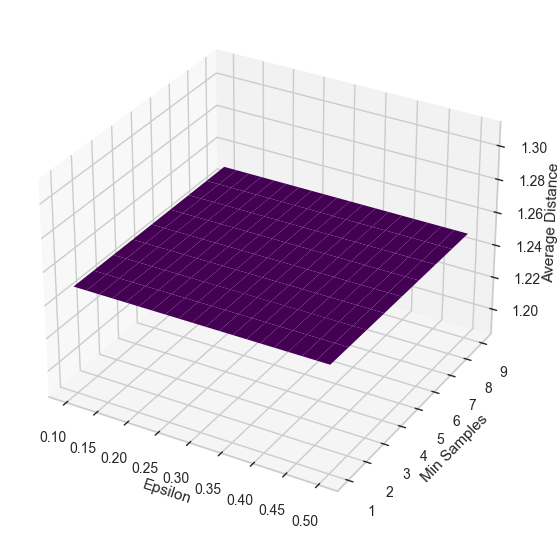

Optimal Min Samples: 1
Optimal Epsilon: 0.1


In [125]:
optimal_min_samples, optimal_epsilon = elbow_method_samples(df_return, range(1, 10),np.linspace(0.1, 0.5, num=20) )

In [126]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

def elbow_method_samples_2D(data, min_samples_range=None, epsilon_range=None):
    '''
    data : df
    min_samples_range : plage de nombre à tester représentant le nombre d'échantillons min par cluster
    epsilon_range : plage de valeurs d'epsilon à tester
    NB : min_samples_range et epsilon_range ne forcent pas les valeurs, elles indiquent une préférence
    '''
    if min_samples_range is None:
        min_samples_range = range(1, 10)
    if epsilon_range is None:
        epsilon_range = np.linspace(0.1, 2.0, num=20)  # Ajustez la plage selon vos besoins

    # Sélectionner uniquement les colonnes numériques
    numeric_columns = data.select_dtypes(include=[np.number]).columns
    df_numeric = data[numeric_columns]

    # Appliquer la mise à l'échelle et l'ACP
    data_pca, _, _ = scale_and_pca(df_numeric)

    avg_distances = []
    for epsilon in epsilon_range:
        avg_distances_epsilon = []
        for min_samples in min_samples_range:
            dbscan = DBSCAN(eps=epsilon, min_samples=min_samples)
            clusters = dbscan.fit_predict(data_pca)

            neighbors = NearestNeighbors(n_neighbors=2)
            neighbors.fit(data_pca)
            distances, _ = neighbors.kneighbors(data_pca)

            avg_distance = np.mean(distances[:, 1])
            avg_distances_epsilon.append(avg_distance)

        avg_distances.append(avg_distances_epsilon)

    # Tracer la courbe des distances moyennes en fonction du nombre minimum d'échantillons
    avg_distances_array = np.array(avg_distances)
    plt.plot(min_samples_range, avg_distances_array.T, marker='o')
    plt.title('Elbow Method for Optimal Min Samples (DBSCAN)')
    plt.xlabel('Min Samples')
    plt.ylabel('Average Distance')
    plt.show()

    # Trouver l'indice du coude (point où la pente change)
    elbow_index = np.argmin(np.gradient(avg_distances_array))

    # Imprimer le nombre optimal de min_samples au coude
    optimal_min_samples = min_samples_range[elbow_index]
    optimal_epsilon = epsilon_range[np.argmin(avg_distances_array[:, elbow_index])]
    print(f'Optimal Min Samples: {optimal_min_samples}')
    print(f'Optimal Epsilon: {optimal_epsilon}')

    return optimal_min_samples, optimal_epsilon


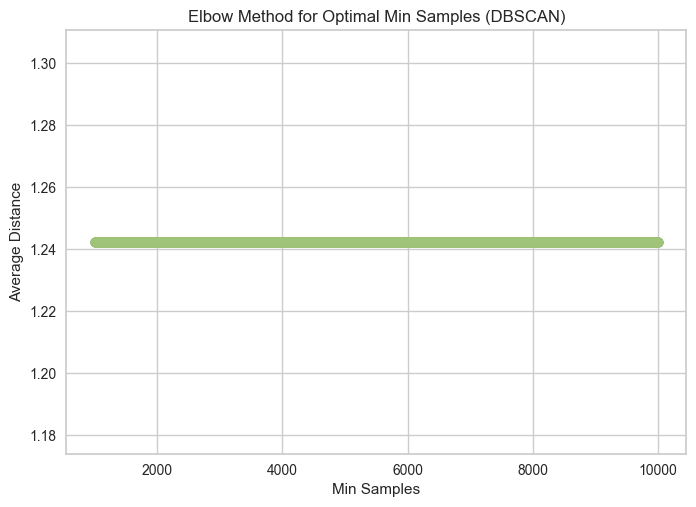

Optimal Min Samples: 1000
Optimal Epsilon: 0.0001


In [147]:
optimal_min_samples, optimal_epsilon = elbow_method_samples_2D(df_pieces, range(1000, 10000),np.linspace(0.0001, 2, num=2) )

In [11]:
from skopt import BayesSearchCV
from sklearn.base import BaseEstimator, ClusterMixin
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import numpy as np

class DBSCANEstimator(BaseEstimator, ClusterMixin):
    def __init__(self, eps, min_samples):
        self.eps = eps
        self.min_samples = min_samples

    def fit(self, X, y=None):
        self.dbscan = DBSCAN(eps=self.eps, min_samples=self.min_samples)
        self.labels_ = self.dbscan.fit_predict(X)
        return self

# Définissez la fonction objectif
def objective(params):
    eps, min_samples = params['eps'], params['min_samples']

    # Créez une instance de DBSCANEstimator avec les paramètres donnés
    dbscan_estimator = DBSCANEstimator(eps=eps, min_samples=min_samples)
    dbscan_estimator.fit(df_pieces_indexed)

    # Calculez le score de silhouette
    silhouette_avg = silhouette_score(df_pieces_indexed, dbscan_estimator.labels_)

    # Nous voulons maximiser le score de silhouette, donc nous renvoyons son négatif
    return -silhouette_avg

# Utilisez BayesSearchCV avec la nouvelle classe DBSCANEstimator
param_space = {'eps': (0.1, 1.0), 'min_samples': (2, 10)}
dbscan_estimator = DBSCANEstimator(eps=0.5, min_samples=5)  # Créez une instance
opt = BayesSearchCV(dbscan_estimator, search_spaces=param_space, n_iter=20, random_state=42, n_jobs=-1, scoring=objective)
opt.fit(df_pieces_indexed)

# Obtenez les meilleurs paramètres trouvés
best_params = opt.best_params_

print("Meilleurs paramètres pour DBSCAN :", best_params)


AttributeError: module 'numpy' has no attribute 'int'.
`np.int` was a deprecated alias for the builtin `int`. To avoid this error in existing code, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

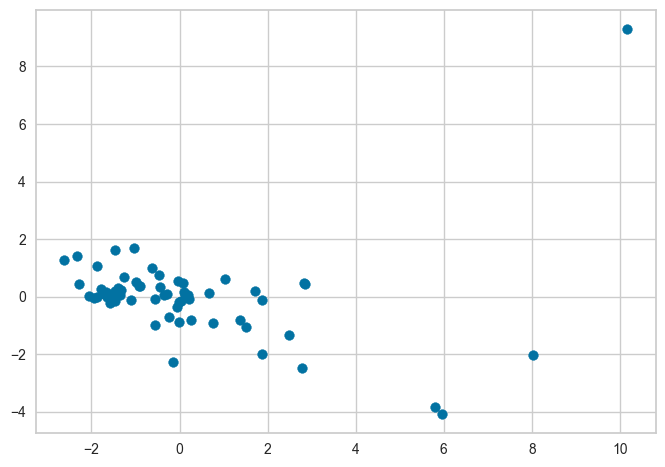

In [159]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.show()

In [133]:
optimal_epsilon = 1.25  # Remplacez par la valeur que vous avez trouvée avec la méthode du coude
optimal_min_samples = 2
df_result = clustering_dbscan(df_return, eps=optimal_epsilon, min_samples=optimal_min_samples)

plot_dataframe(df_result)

In [132]:
optimal_epsilon = 1.25  # Remplacez par la valeur que vous avez trouvée avec la méthode du coude
optimal_min_samples = 2
df_result = clustering_dbscan(df_pieces, eps=optimal_epsilon, min_samples=optimal_min_samples)

plot_dataframe(df_result)

In [131]:
df_pieces

,Fichier,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre
0,AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,2.571505e+02,1.826662e+02,-96.195630,213,624,414,450.067130
1,AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,2.571505e+02,-1.826662e+02,-96.195636,213,624,414,450.067155
2,AR00000205467.stp,1.898665e+05,4.130813e+04,220.000000,24.000000,181.000000,2.891910e-05,1.408070e+01,84.286914,38,108,72,285.896835
3,AR00000206023.stp,4.358866e+06,4.543543e+05,45.000000,710.000000,267.000000,-1.736312e+01,8.239296e-06,136.147088,252,614,385,759.877622
4,AR00000228600.stp,1.032005e+06,2.880238e+05,320.000000,320.000000,66.000000,-3.011698e-14,7.918778e-14,-18.799865,33,66,38,457.335763
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,M3D-252795_--A_CATPART_0.stp,1.710421e+06,6.105035e+05,308.000000,298.500000,517.873929,3.449692e+01,-1.958349e+02,-3.316853,741,1797,1174,672.428179
63,M3D-253216_--B_CATPART_1.stp,2.684166e+05,1.502797e+05,147.800000,145.000000,661.568543,3.749776e+01,-1.224952e+00,258.610308,106,307,205,693.211928
64,M3D-254068_--A_CATPART_1.stp,2.761165e+05,8.246681e+04,250.000000,250.000000,7.500000,-3.370476e-15,2.967552e-15,3.750000,6,12,8,353.632931
65,M3D-255359_--A_CATPART_0.stp,7.261777e+07,3.077499e+06,1206.000000,206.000000,1206.000000,9.686022e-09,5.959078e+00,-0.002406,104,222,133,1717.937135


c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning:

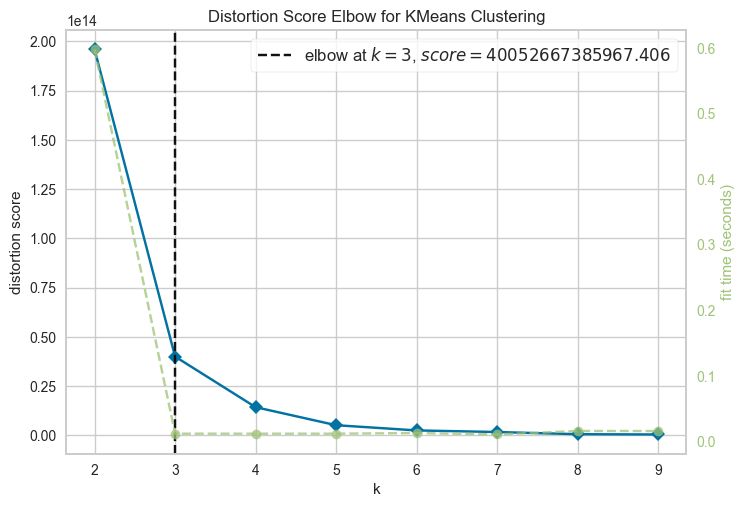

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [5]:
from sklearn import datasets
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

# Instantiate the clustering model
km = KMeans(random_state=42)

# Instantiate the KElbowVisualizer with the KMeans model
visualizer = KElbowVisualizer(km, k=(2, 10))

# Fit the data to the visualizer (assuming your data is in the numeric columns of df)
visualizer.fit(df_pieces_indexed)

# Finalize and render the figure
visualizer.show()

In [12]:
import plotly.graph_objects as go
from sklearn.cluster import KMeans
import pandas as pd

# Suppose df_pieces_indexed is your DataFrame
# df_pieces_indexed = pd.read_csv('your_dataframe.csv', index_col='Fichier')

# K-means using k = 3
kmeans = KMeans(n_clusters=10)
kmeans.fit(df_pieces_indexed)
y_kmeans = kmeans.predict(df_pieces_indexed)

col_x = "Volume"
col_y = "Surface"
col_z = "Faces"

# 3D plot
scene = dict(xaxis=dict(title=col_x), yaxis=dict(title=col_y), zaxis=dict(title=col_z))

labels = kmeans.labels_
trace = go.Scatter3d(
    x=df_pieces_indexed[col_x],
    y=df_pieces_indexed[col_y],
    z=df_pieces_indexed[col_z],
    mode='markers',
    marker=dict(color=labels, size=10, line=dict(color='black', width=10))
)
layout = go.Layout(margin=dict(l=0, r=0), scene=scene, height=800, width=800)
data = [trace]
fig = go.Figure(data=data, layout=layout)
fig.show()


c:\Users\kevin\anaconda3\envs\Alstom\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [6]:
df_pieces_indexed

,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre
Fichier,,,,,,,,,,,,
AR00000081181.stp,1.034015e+06,1.661971e+05,285.892305,199.000028,285.000000,2.571505e+02,1.826662e+02,-96.195630,213,624,414,450.067130
AR00000081182.stp,1.034015e+06,1.661971e+05,285.892305,199.000085,285.000000,2.571505e+02,-1.826662e+02,-96.195636,213,624,414,450.067155
AR00000205467.stp,1.898665e+05,4.130813e+04,220.000000,24.000000,181.000000,2.891910e-05,1.408070e+01,84.286914,38,108,72,285.896835
AR00000206023.stp,4.358866e+06,4.543543e+05,45.000000,710.000000,267.000000,-1.736312e+01,8.239296e-06,136.147088,252,614,385,759.877622
AR00000228600.stp,1.032005e+06,2.880238e+05,320.000000,320.000000,66.000000,-3.011698e-14,7.918778e-14,-18.799865,33,66,38,457.335763
...,...,...,...,...,...,...,...,...,...,...,...,...
M3D-252795_--A_CATPART_0.stp,1.710421e+06,6.105035e+05,308.000000,298.500000,517.873929,3.449692e+01,-1.958349e+02,-3.316853,741,1797,1174,672.428179
M3D-253216_--B_CATPART_1.stp,2.684166e+05,1.502797e+05,147.800000,145.000000,661.568543,3.749776e+01,-1.224952e+00,258.610308,106,307,205,693.211928
M3D-254068_--A_CATPART_1.stp,2.761165e+05,8.246681e+04,250.000000,250.000000,7.500000,-3.370476e-15,2.967552e-15,3.750000,6,12,8,353.632931


# Similarité encore

In [54]:
df_pieces[(df_pieces["Fichier"] == "M3D-224712_B.stp") | (df_pieces["Fichier"] == "M3D-224710_B.stp")]

,Fichier,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre
43,M3D-224710_B.stp,4.259958e+06,700505.007179,352.0,242.0,575.0,23.583199,-25.830608,-271.079108,170,446,296,716.305103
44,M3D-224712_B.stp,4.259958e+06,700505.007179,352.0,242.0,575.0,23.583199,25.830608,-271.079108,170,446,296,716.305103


In [53]:
df_pieces[(df_pieces["Fichier"] == "M3D-224712_B.stp") | (df_pieces["Fichier"] == "M3D-224710_B.stp")].set_index("Fichier").pct_change()


,Volume,Surface,Lng_BBox,Lrg_BBox,Hauteur_BBox,Cx,Cy,Cz,Faces,Aretes,Sommets,Diametre
Fichier,,,,,,,,,,,,
M3D-224710_B.stp,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M3D-224712_B.stp,-2.220446e-16,2.220446e-16,0.0,0.0,0.0,-2.109424e-15,-2.0,2.220446e-16,0.0,0.0,0.0,0.0


On fait la différence entre la pièce et son voisin, on obtient un ratio en prct 

In [119]:
# Sélectionner les lignes pour lesquelles tu veux calculer le pourcentage de changement
# selected_rows = df_pieces[(df_pieces["Fichier"] == "M3D-224712_B.stp") | (df_pieces["Fichier"] == "M3D-224710_B.stp")]

# selected_rows = pd.concat([df_pieces[df_pieces["Fichier"] == "M3D-224710_B.stp"],
#                            df_pieces[df_pieces["Fichier"] == "M3D-224712_B.stp"]])
# selected_rows = pd.concat([df_pieces[df_pieces["Fichier"] == "AR00000081181.stp"],
#                            df_pieces[df_pieces["Fichier"] == "AR00000081182.stp"]])
selected_rows = pd.concat([df_pieces[df_pieces["Fichier"] == "AR00000205467.stp"],
                           df_pieces[df_pieces["Fichier"] == "AR00000081181.stp"]])

# Calculer le pourcentage de changement
percentage_change_df = selected_rows.set_index("Fichier").pct_change()

# Calculer la moyenne entre les variables (colonnes)
average_percentage_change = percentage_change_df.mean(axis=1).iloc[1]


similarity = round(100 - abs(percentage_change_df.mean(axis=1).iloc[1] *100) ,2)

if similarity < 0:
    similarity = 0

print(similarity)
# si on à 0, mêmes pièces
# si négatif, pièce voisine plus petite que pièce initiale
# si positif, pièce voisine plus grande que pièce initiale
# J'en conclus que plus on se rapproche de 0, plus elles sont similaires
# Donc si je prends la valeur absolu j'obtiens le taux de similarité
# Nb: même si on ne prend que les caractéristiques et non la forme des pièces, on sait que les pièces sont voisines,
# donc assez similaires selon l'acp

0


In [113]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sélectionner les lignes pour lesquelles tu veux calculer le pourcentage de changement
selected_rows = pd.concat([df_pieces[df_pieces["Fichier"] == "AR00000081182.stp"],
                           df_pieces[df_pieces["Fichier"] == "AR00000081181.stp"]])

# Extraire les caractéristiques géométriques
# Supposer que `df_pieces` contient toutes les caractéristiques nécessaires
features = df_pieces.set_index("Fichier")

# Centrer et réduire les données
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Appliquer l'ACP
pca = PCA()
features_pca = pca.fit_transform(features_scaled)

# Convertir les composantes principales en DataFrame
df_pca = pd.DataFrame(features_pca, columns=[f'PC{i+1}' for i in range(features_pca.shape[1])])

# Ajouter les colonnes de composantes principales à la sélection
selected_rows_with_pca = pd.concat([selected_rows.set_index("Fichier"), df_pca], axis=1)

# Calculer le pourcentage de changement
percentage_change_df = selected_rows_with_pca.pct_change()

# Calculer la moyenne entre les variables (colonnes)
average_percentage_change = percentage_change_df.mean(axis=1).iloc[1]

# Calculer le taux de similarité
similarity = round(100 - abs(average_percentage_change * 100), 2)

# Si similarity est négatif, le mettre à 0
similarity = max(0, similarity)

print(similarity)


83.33


C:\Users\kevin\AppData\Local\Temp\ipykernel_2568\1580757549.py:28: FutureWarning:

The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



In [81]:
distance

3269892.151454608